In [1]:
import pandas as pd
import joblib

In [2]:
df = pd.read_csv("../data/processed/planet_classes.csv")

model = joblib.load(
    "../models/logistic_classifier.pkl"
)

In [4]:
X = df[
    [
        "log_pl_rade",
        "log_pl_bmasse",
        "log_pl_dens",
        "log_pl_orbsmax"
    ]
]

X.shape

(6298, 4)

In [ ]:
import shap
shap.__version__

'0.52.0'

In [7]:
explainer = shap.Explainer(
    model,
    X
)
type(explainer)

Background dataset has 6298 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=6298 when initializing the masker.


shap.explainers._linear.LinearExplainer

In [8]:
shap_values = explainer(X)
shap_values.shape

(6298, 4, 4)

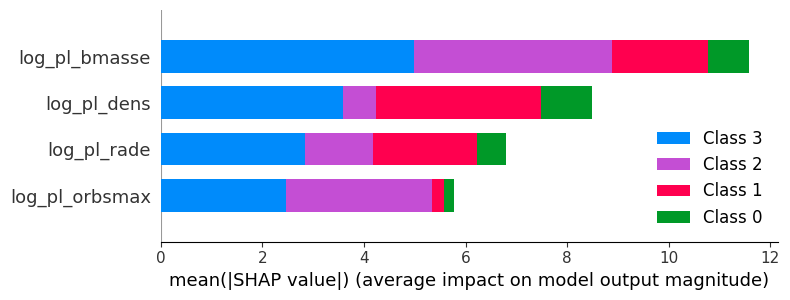

In [9]:
shap.summary_plot(
    shap_values,
    X,
    feature_names=X.columns
)

SHAP analysis revealed that planetary mass was the strongest driver of cluster classification, followed by density and radius. Orbital distance contributed less strongly, suggesting that the discovered planetary archetypes are primarily distinguished by intrinsic physical properties rather than orbital location.

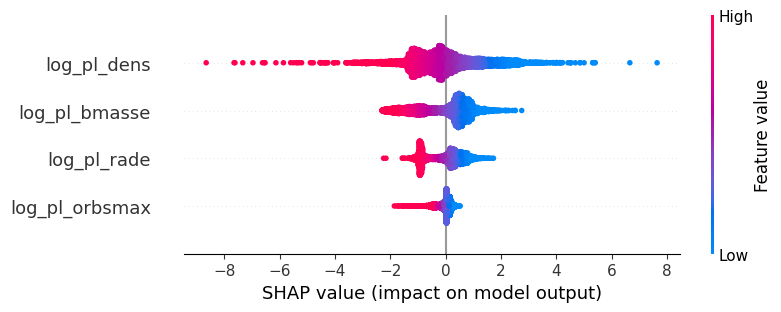

In [11]:
shap.plots.beeswarm(shap_values[:, :, 0])

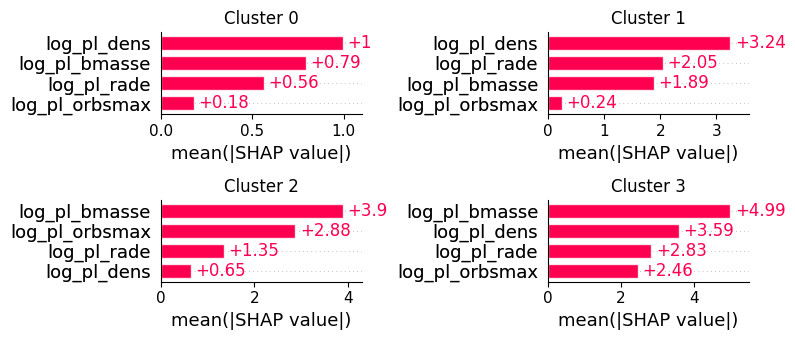

In [16]:
import matplotlib.pyplot as plt
import shap

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, ax in enumerate(axes.flatten()):
    plt.sca(ax)

    shap.plots.bar(
        shap_values[:, :, i],
        show=False
    )

    ax.set_title(f"Cluster {i}")

plt.tight_layout()
plt.show()

Two planetary populations are primarily distinguished by density (likely reflecting internal composition), while two others are primarily distinguished by mass (reflecting giant-planet regimes).